# GeomechPy — Deviation, Azimuth & Near-Wellbore Stresses

**How does well trajectory change the geomechanics?**

A key idea in wellbore geomechanics: the **far-field earth stresses** (pore pressure, overburden
$S_v$, and the horizontal stresses $S_{hmin}$, $S_{Hmax}$) are properties of the *formation*. They do
**not** depend on how you drill through it. What the well trajectory changes is the **near-wellbore
stress concentration** — and therefore the mud weight window, the location of borehole breakouts, and
the location of drilling-induced tensile fractures (DITFs).

This notebook shows, step by step:

1. [The far-field MEM is trajectory-independent](#1)
2. [Deviation narrows (and can close) the mud weight window](#2)
3. [Azimuth matters too](#3)
4. [Near-wellbore stresses around the borehole wall (the Kirsch solution)](#4)
5. [Mud weight reshapes the hoop stress](#5)
6. [Reading it on LWD images: breakouts and tensile fractures](#6)

These effects are the physical basis for interpreting **Logging-While-Drilling (LWD) borehole images**
for geomechanical analysis: breakouts and tensile fractures seen on the image directly constrain the
in-situ stress magnitudes and orientations.

> Install: `pip install .[plotting]` from the repository root.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from geomechpy import (
    MechanicalEarthModel,
    NearWellboreStressesCalculation,
    WellboreStabilityCalculation,
    HorizontalStressesCalculation,
    UnitConverter,
    plot_borehole_wall_stresses,
)

<a id="1"></a>
## 1. The far-field MEM is trajectory-independent

We build a 1D Mechanical Earth Model from synthetic logs (see `02_full_mem_workflow.ipynb` for the
full chain). The far-field stresses below are what the rock *is* — they are the inputs to every
trajectory calculation that follows.

In [2]:
rng = np.random.default_rng(7)
tvd = np.arange(9000.0, 11000.0 + 25.0, 25.0)          # ft
trend = (tvd - tvd[0]) / (tvd[-1] - tvd[0])
noise = rng.normal(0.0, 1.0, len(tvd)).cumsum() / np.sqrt(len(tvd))

mem = MechanicalEarthModel(
    tvd=tvd.tolist(),
    dtco=(84.0 - 12.0 * trend + 1.0 * noise).tolist(),   # us/ft
    dtsh=(150.0 - 24.0 * trend + 1.6 * noise).tolist(),  # us/ft
    rhob=(2500.0 + 120.0 * trend - 5.0 * noise).tolist() # kg/m3
)
mem.calculate_all(pore_pressure_gradient=9.2, gradient_unit="ppg", stress_method="eaton", shmax_multiplier=1.15)

# Far-field stresses at total depth
td = mem.results
i = -1
Sv, SHmax, Shmin, Pp = td["overburden"][i], td["shmax"][i], td["shmin"][i], td["pore_pressure"][i]
regime = HorizontalStressesCalculation.classify_stress_regime(Sv, SHmax, Shmin)
print(f"At {tvd[-1]:.0f} ft:  Pp={Pp:.0f}  Shmin={Shmin:.0f}  SHmax={SHmax:.0f}  Sv={Sv:.0f} psi")
print(f"Faulting regime: {regime}")

At 11000 ft:  Pp=5257  Shmin=7607  SHmax=8748  Sv=11979 psi
Faulting regime: Normal faulting


<a id="2"></a>
## 2. Deviation narrows — and can close — the mud weight window

For a **vertical** well the mud weight window is symmetric and widest. As the well is **deviated**, the
axial stress and the shear terms in the near-wellbore solution grow, concentrating stress on the wall.
The safe window between the breakout limit (collapse) and the loss/breakdown limit shrinks. In a weak
formation it can **close entirely** — no mud weight keeps the hole in gauge.

We sweep deviation from vertical to horizontal at fixed azimuth and plot the equivalent-mud-weight
window at total depth.

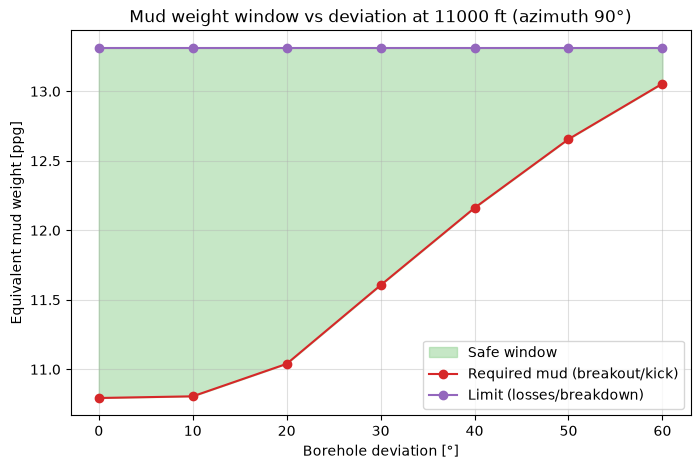

Window is open up to ~60° deviation; closes beyond that in this rock.


In [3]:
strength = dict(ucs=td["ucs"][i], fang=td["fang"][i], pr_sta=td["sta_poissons_ratio"][i], tstr=td["tstr"][i])
depth = tvd[-1]

deviations = list(range(0, 91, 10))
lowers, uppers = [], []
for dev in deviations:
    try:
        w = WellboreStabilityCalculation.calculate_mud_weight_window_deviated_well(
            shmax=SHmax, shmin=Shmin, pprs=Pp, overburden_stress=Sv, **strength,
            borehole_deviation=float(dev), borehole_azimuth=90.0, shmax_azimuth=0.0)
        lo = UnitConverter.convert_pressure_to_mud_weight(max(w.kick_pressure, w.breakout_pressure), depth)
        hi = UnitConverter.convert_pressure_to_mud_weight(min(w.loss_pressure, w.breakdown_pressure), depth)
        lowers.append(lo if hi > lo else np.nan)
        uppers.append(hi if hi > lo else np.nan)
    except ValueError:
        lowers.append(np.nan); uppers.append(np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(deviations, lowers, uppers, color="#8fd18f", alpha=0.5, label="Safe window")
ax.plot(deviations, lowers, "o-", color="#d62728", label="Required mud (breakout/kick)")
ax.plot(deviations, uppers, "o-", color="#9467bd", label="Limit (losses/breakdown)")
ax.set_xlabel("Borehole deviation [°]"); ax.set_ylabel("Equivalent mud weight [ppg]")
ax.set_title(f"Mud weight window vs deviation at {depth:.0f} ft (azimuth 90°)")
ax.grid(alpha=0.4); ax.legend()
plt.show()

last_open = max([d for d, lo in zip(deviations, lowers) if lo == lo], default=None)
print(f"Window is open up to ~{last_open}° deviation; closes beyond that in this rock.")

The window is widest for the vertical well and narrows as the well is deviated, closing at high
angle. This is exactly the analysis used to decide whether a planned high-angle or horizontal section
is drillable, or whether the casing shoe must be set deeper.

<a id="3"></a>
## 3. Azimuth matters too

At a fixed deviation, the **direction** the well is drilled relative to the horizontal stresses changes
stability. Drilling parallel vs perpendicular to $S_{Hmax}$ gives different near-wellbore stress
concentrations. We fix deviation at 60° and sweep the borehole azimuth.

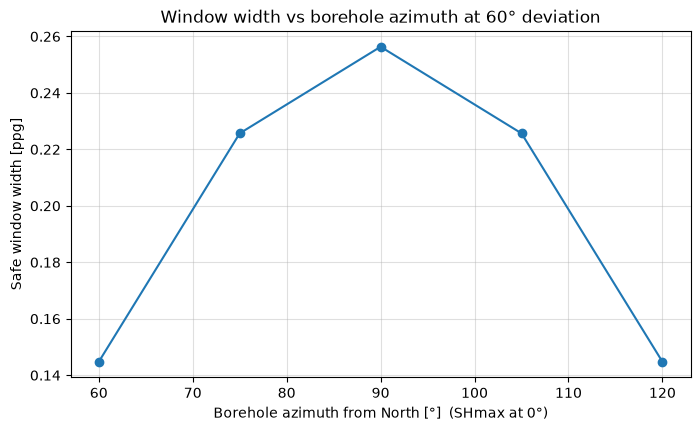

Widest (most stable) azimuth: 90 ° from North


In [4]:
azimuths = list(range(0, 181, 15))
lo_az, hi_az = [], []
for az in azimuths:
    try:
        w = WellboreStabilityCalculation.calculate_mud_weight_window_deviated_well(
            shmax=SHmax, shmin=Shmin, pprs=Pp, overburden_stress=Sv, **strength,
            borehole_deviation=60.0, borehole_azimuth=float(az), shmax_azimuth=0.0)
        lo = UnitConverter.convert_pressure_to_mud_weight(max(w.kick_pressure, w.breakout_pressure), depth)
        hi = UnitConverter.convert_pressure_to_mud_weight(min(w.loss_pressure, w.breakdown_pressure), depth)
        lo_az.append(lo if hi > lo else np.nan); hi_az.append(hi if hi > lo else np.nan)
    except ValueError:
        lo_az.append(np.nan); hi_az.append(np.nan)

widths = [(h - l) if (h == h and l == l) else np.nan for l, h in zip(lo_az, hi_az)]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(azimuths, widths, "o-", color="#1f77b4")
ax.set_xlabel("Borehole azimuth from North [°]  (SHmax at 0°)")
ax.set_ylabel("Safe window width [ppg]")
ax.set_title("Window width vs borehole azimuth at 60° deviation")
ax.grid(alpha=0.4)
plt.show()
print("Widest (most stable) azimuth:", azimuths[int(np.nanargmax(widths))], "° from North")

The most stable drilling direction depends on the stress regime. This is why well-planning in a
known stress field chooses the trajectory that maximises the mud-weight margin.

<a id="4"></a>
## 4. Near-wellbore stresses around the borehole wall (Kirsch solution)

To *see why*, look at the stresses on the borehole wall itself. The **Kirsch solution** gives the
effective **hoop (tangential)**, **axial** and **radial** stresses as a function of the azimuthal
position $\theta$ around the wall (measured from the top of hole):

- **Breakouts** (compressive shear failure) initiate where the **hoop stress is highest**.
- **Drilling-induced tensile fractures** initiate where the **hoop stress is lowest** (and goes below
  the rock's tensile strength).

Compare a vertical well with a 60° deviated well at the same depth and mud weight.

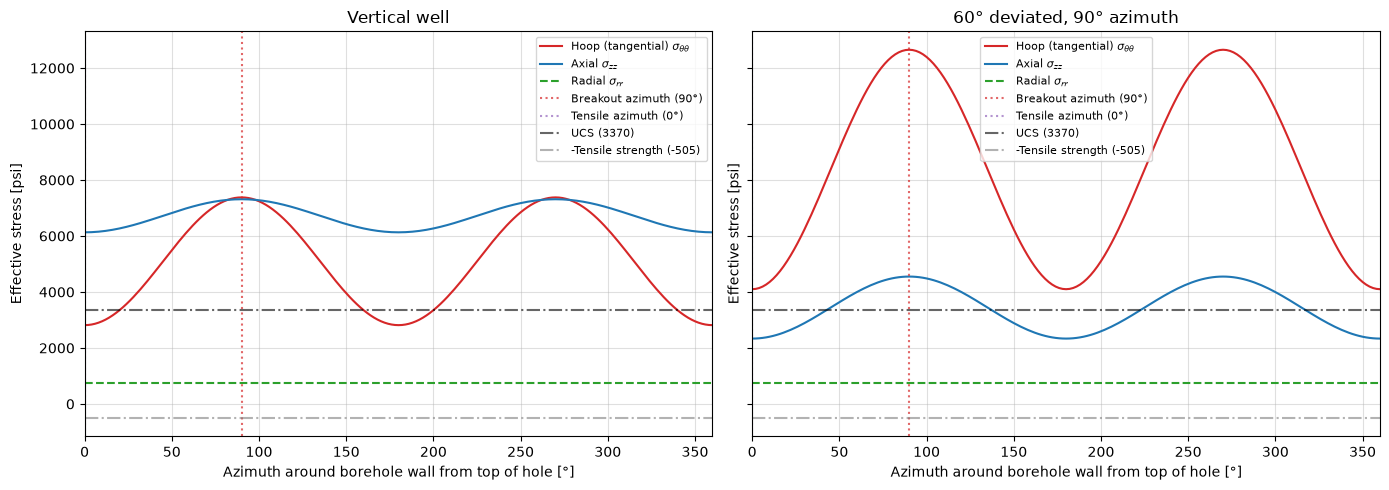

In [5]:
theta = np.linspace(0.0, 360.0, 181)
mud_psi = UnitConverter.convert_mud_weight_to_pressure(10.5, depth)   # 10.5 ppg -> psi

def wall(dev, az):
    return NearWellboreStressesCalculation.calculate_kirsch_borehole_wall_stresses(
        shmin=Shmin, shmax=SHmax, svert=Sv, pore_pressure=Pp, shmax_azimuth=0.0,
        mud_pressure=mud_psi, theta=theta, poisson_ratio_static=strength["pr_sta"],
        borehole_deviation=dev, borehole_azimuth=az)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (dev, az, label) in zip(axes, [(0.0, 0.0, "Vertical well"), (60.0, 90.0, "60° deviated, 90° azimuth")]):
    plot_borehole_wall_stresses(theta, wall(dev, az), ucs=strength["ucs"], tensile_strength=strength["tstr"], ax=ax)
    ax.set_title(label)
plt.tight_layout(); plt.show()

In the vertical well the hoop-stress curve has two clean maxima 180° apart (the breakout azimuth,
perpendicular to $S_{Hmax}$) and two minima 180° apart (the tensile-fracture azimuth, parallel to
$S_{Hmax}$). Deviating the well shifts and reshapes the curves — the axial stress $\sigma_{zz}$
changes markedly, and the breakout azimuth rotates — which is exactly what changes the mud weight
window.

<a id="5"></a>
## 5. Mud weight reshapes the hoop stress

The radial stress on the wall equals the mud pressure (minus pore pressure). Raising the mud weight
supports the wall and **lowers the hoop stress** — reducing breakout risk — but pushes the minimum
hoop stress toward (and past) the tensile limit, **increasing tensile-fracture risk**. This trade-off
is the whole point of the mud weight window.

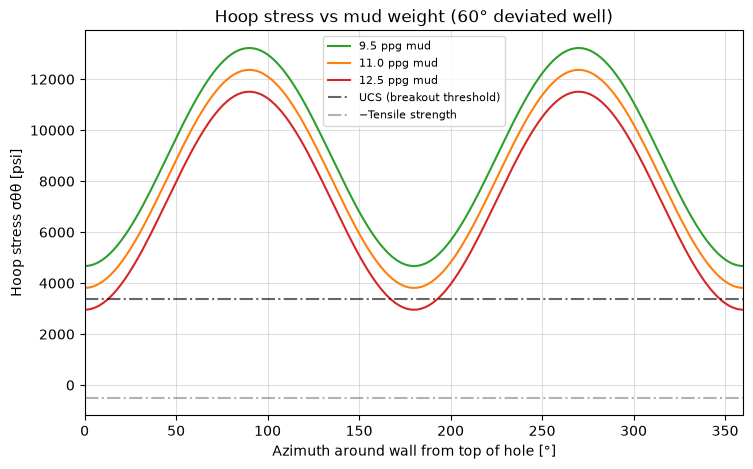

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for mw, color in [(9.5, "#2ca02c"), (11.0, "#ff7f0e"), (12.5, "#d62728")]:
    w = NearWellboreStressesCalculation.calculate_kirsch_borehole_wall_stresses(
        shmin=Shmin, shmax=SHmax, svert=Sv, pore_pressure=Pp, shmax_azimuth=0.0,
        mud_pressure=UnitConverter.convert_mud_weight_to_pressure(mw, depth), theta=theta,
        poisson_ratio_static=strength["pr_sta"], borehole_deviation=60.0, borehole_azimuth=90.0)
    ax.plot(theta, w.sigma_tt, color=color, label=f"{mw:.1f} ppg mud")
ax.axhline(strength["ucs"], color="black", linestyle="-.", alpha=0.6, label="UCS (breakout threshold)")
ax.axhline(-strength["tstr"], color="gray", linestyle="-.", alpha=0.6, label="−Tensile strength")
ax.set_xlabel("Azimuth around wall from top of hole [°]"); ax.set_ylabel("Hoop stress σθθ [psi]")
ax.set_title("Hoop stress vs mud weight (60° deviated well)")
ax.grid(alpha=0.4); ax.legend(fontsize=8); ax.set_xlim(0, 360)
plt.show()

As mud weight increases the whole hoop-stress curve drops: the peaks (where breakouts form) move
below UCS — good — but the troughs approach $-T_0$, where tensile fractures open. The safe window is
the mud weight range that keeps the peaks below the breakout strength **and** the troughs above the
tensile limit.

<a id="6"></a>
## 6. Reading it on LWD images

On a **Logging-While-Drilling borehole image**, these stress concentrations are directly visible and
are the primary geomechanical observables:

- **Breakouts** appear as two **broad, conductive (dark) zones 180° apart**, centred on the azimuth of
  maximum hoop stress. In a vertical well that azimuth is **perpendicular to $S_{Hmax}$** — so breakouts
  point at $S_{hmin}$ and give the horizontal stress *orientation* directly.
- **Drilling-induced tensile fractures** appear as two **narrow, resistive (light) features 180° apart**,
  ~90° from the breakouts, aligned with **$S_{Hmax}$**.
- Their **width and occurrence** constrain the stress **magnitudes** and rock strength (via exactly the
  Kirsch + failure-criterion calculation above).

So the near-wellbore model in this notebook is the forward model behind LWD image interpretation:
given stresses and trajectory it predicts where failure occurs; given the observed failures on the
image, it inverts to the stresses. The interactive **GeomechPy Dashboard**
(`examples/streamlit_apps/geomechpy_dashboard.py`) lets you explore all of this live — sweep deviation,
azimuth and mud weight and watch the wall stresses and mud weight window respond.

*Reference: Logging-While-Drilling images for geomechanical, geological and petrophysical
interpretation; and Fjaer et al., Petroleum Related Rock Mechanics (2008), Ch. 4; Zoback, Reservoir
Geomechanics (2010), Ch. 6–10.*